In [1]:
#Phase 1: load,explore & clean
#In this noyebook, im starting Phase 1 of the capstone project.
#I'll load the titanic dataset, take a quick look at it , and clean it up
#This includes fixing column types, filling missing values , removing duplicates,and capping extreme numbers so the data is ready for analysis.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [3]:
#load data
#we read the csv file into a dataframe and look at the first few rows.

In [4]:
#load data

url_train= "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url_train)

#show first 5 rows to see the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Phase 2: Feature Engineering – Titanic Dataset

In [6]:
# Step 1: One-Hot Encoding
# We convert categorical columns into numerical binary columns so they can be used in analysis and modeling.
# Here, 'Sex' and 'Embarked' are categorical columns.

In [7]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)  # drop_first=True to avoid redundant reference column
df.head()  # Check the new one-hot encoded columns

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True


In [8]:
# Step 2: Ordinal Encoding

In [9]:
# Some columns are naturally ordered, like 'Pclass'. We convert it to integer type to preserve the order.
df["Pclass_ord"] = df["Pclass"].astype(int)  # 1=highest class, 3=lowest
df["Pclass_ord"].head()  # Verify the values


,Pclass_ord
0,3
1,1
2,3
3,1
4,3


In [10]:
# Step 3: Scaling Numerical Columns

In [11]:
# Scaling ensures numerical columns like 'Age' and 'Fare' have mean 0 and std 1, which helps with analysis and modeling.
scaler = StandardScaler()
df[["Age_scaled", "Fare_scaled"]] = scaler.fit_transform(df[["Age", "Fare"]])  # Scale Age and Fare
df[["Age_scaled", "Fare_scaled"]].head()  # Check scaled values

,Age_scaled,Fare_scaled
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


In [12]:
# Step 4: Create Domain Features

In [13]:
# Domain features provide extra insights by combining existing columns.
# 1. Fare per Age ratio
# 2. Interaction between Pclass and Age

In [14]:
df["Fare_per_Age"] = df["Fare"] / (df["Age"] + 1e-5)  # Avoid division by zero
df["Pclass_x_Age"] = df["Pclass_ord"] * df["Age"]  # Interaction feature
df[["Fare_per_Age", "Pclass_x_Age"]].head()  # Check new features

,Fare_per_Age,Pclass_x_Age
0,0.329545,66.0
1,1.875876,38.0
2,0.304808,78.0
3,1.517142,35.0
4,0.230000,105.0


In [15]:
# Step 5: Log Transform Skewed Column

<Axes: >

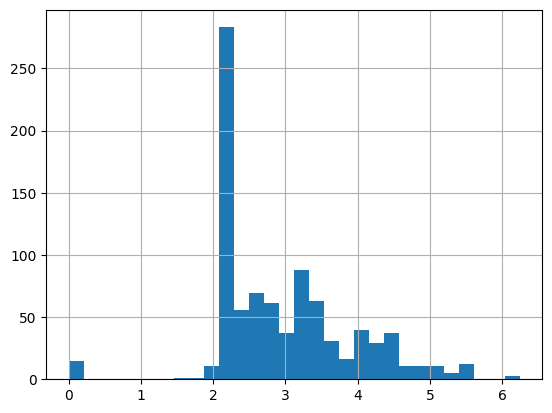

In [16]:
# Log transformation reduces skewness in heavily skewed columns like 'Fare'.
df["Fare_log"] = np.log1p(df["Fare"])  # np.log1p handles zero values
df["Fare_log"].hist(bins=30)  # Visual check

In [17]:
# Step 6: Bin Age

In [18]:
# Binning Age into groups makes it easier to compare age categories.
df["Age_group"] = pd.cut(df["Age"], bins=[0, 18, 60, 100], labels=["Young", "Adult", "Senior"])
df[["Age", "Age_group"]].head()  # Verify bins

,Age,Age_group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


In [19]:
# Step 7: Remove Redundant Features

In [20]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Find highly correlated columns (excluding important ones)
high_corr = [col for col in corr_matrix.columns
             if any(corr_matrix[col] > 0.95)
             and col not in ["Age", "Fare", "Pclass_ord"]]

# Drop only unnecessary highly correlated columns
df = df.drop(columns=high_corr, errors="ignore")